# Olympic Performance Analyzer

## 1. Load Data

In [195]:
import pandas as pd

df = pd.read_csv("../data/raw/athlete_events.csv")
regions = pd.read_csv("../data/raw/noc_regions.csv")

df.shape

(271116, 15)

## 2. Preview Raw Data

In [196]:
df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


## 3. Create Working Copy

In [197]:
clean_df = df.copy()
clean_df.shape

(271116, 15)

## 4. Filter Medal Winners

In [198]:
filtered_df = clean_df[clean_df['Medal'].notnull()]
filtered_df.shape

(39783, 15)

## 5. Deduplicate Team Event Medals

The raw dataset is athlete level so team medals can appear multiple times because every athlete on a team recieves a row and to count actual medals accurately, I deduplicate by Year, Sport, Event, NOC and Medal.

In [199]:
dedup_df = filtered_df.drop_duplicates(subset=["Year", "Sport", "Event", "NOC", "Medal"]).copy()
dedup_df.shape


(18905, 15)

## 6. Create Medal Points Feature

In [200]:
medal_map = {
  "Gold": 3, 
  "Silver": 2, 
  "Bronze": 1
}

dedup_df["Medal_Points"] = dedup_df["Medal"].map(medal_map)
dedup_df.head()


,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,Medal_Points
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,3
37,15,Arvo Ossian Aaltonen,M,30.0,NaN,NaN,Finland,FIN,1920 Summer,1920,Summer,Antwerpen,Swimming,Swimming Men's 200 metres Breaststroke,Bronze,1
38,15,Arvo Ossian Aaltonen,M,30.0,NaN,NaN,Finland,FIN,1920 Summer,1920,Summer,Antwerpen,Swimming,Swimming Men's 400 metres Breaststroke,Bronze,1
40,16,Juhamatti Tapio Aaltonen,M,28.0,184.0,85.0,Finland,FIN,2014 Winter,2014,Winter,Sochi,Ice Hockey,Ice Hockey Men's Ice Hockey,Bronze,1
41,17,Paavo Johannes Aaltonen,M,28.0,175.0,64.0,Finland,FIN,1948 Summer,1948,Summer,London,Gymnastics,Gymnastics Men's Individual All-Around,Bronze,1


### Save Cleaned Dataset

In [201]:
dedup_df.to_csv("../data/processed/olympics_cleaned.csv", index = False)

## 7. Top Countries by Total Medals

In [202]:
top_country_medals = dedup_df.groupby('NOC').size().sort_values(ascending=False)
top_country_medals.head(10)

NOC
USA    2823
URS    1197
GER    1004
GBR     919
FRA     879
ITA     722
SWE     657
CHN     595
RUS     584
GDR     519
dtype: int64

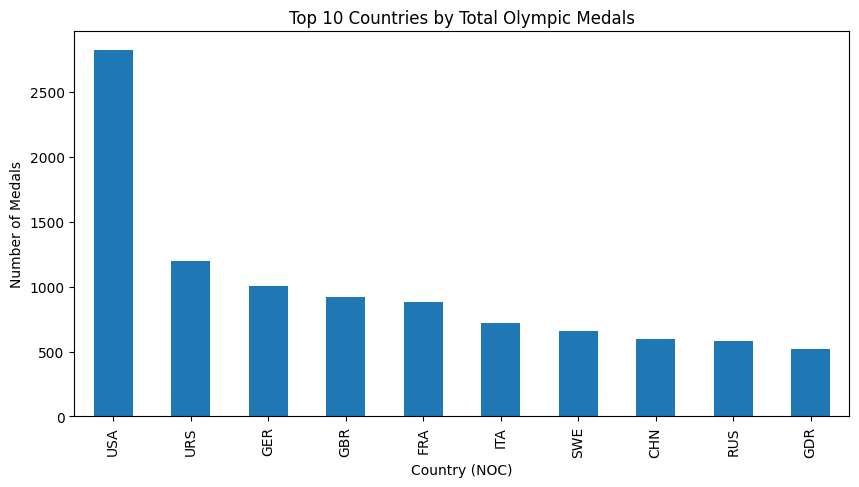

In [203]:
import matplotlib.pyplot as plt

top_country_medals.head(10).plot(kind='bar', title='Top 10 Countries by Total Olympic Medals', xlabel = 'Country (NOC)', ylabel = 'Number of Medals', figsize=(10,5))
plt.show()

## 8. Top Countries by Medal Points

In [204]:
top_country_medal_points = dedup_df.groupby('NOC')['Medal_Points'].sum().sort_values(ascending=False)
top_country_medal_points.head(10)

NOC
USA    5986
URS    2512
GER    1987
GBR    1817
FRA    1693
ITA    1459
SWE    1272
CHN    1257
RUS    1171
GDR    1068
Name: Medal_Points, dtype: int64

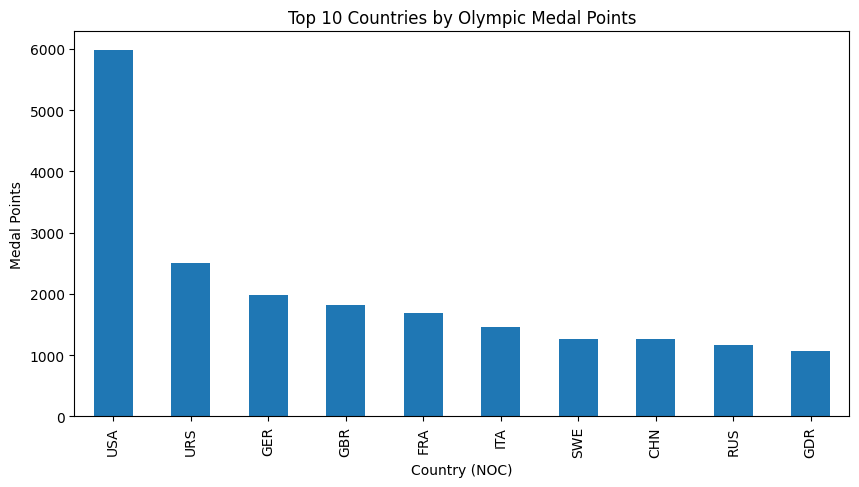

In [205]:
top_country_medal_points.head(10).plot(kind='bar', title='Top 10 Countries by Olympic Medal Points', xlabel='Country (NOC)', ylabel='Medal Points', figsize=(10,5))
plt.show()

## 9. Top Sports by Medals

In [206]:
top_sports_medals = dedup_df.groupby('Sport').size().sort_values(ascending=False)
top_sports_medals.head(10)

Sport
Athletics     3003
Swimming      1685
Wrestling     1296
Gymnastics     974
Boxing         944
Shooting       853
Rowing         783
Cycling        740
Canoeing       679
Fencing        655
dtype: int64

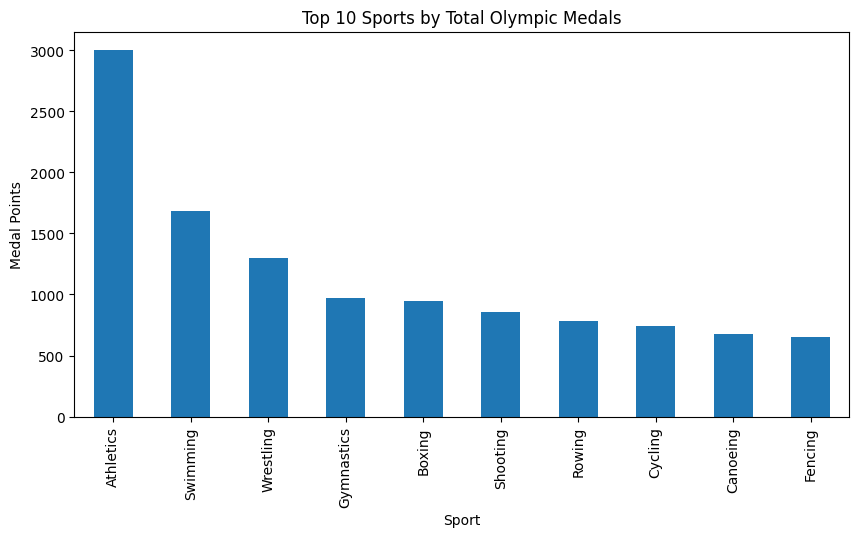

In [ ]:
top_sports_medals.head(10).plot(kind='bar', title='Top 10 Sports by Total Olympic Medals', ylabel='Number of Medals', figsize=(10,5))
plt.show()